<a href="https://colab.research.google.com/github/Thomasjiin/esilv/blob/LLM-%26-genAI/Copie_de_Lab1_VAE_GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1 : Image Generation Models: Autoencoders, GANs and VAEs

In this lab, you will build and train three foundational generative models: Autoencoder, GAN, and VAE.

## Setup

In [ ]:
!pip install torch torchvision matplotlib sklearn

In [ ]:

import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# check if it can be running on Mac M chip
if torch.backends.mps.is_available():
    device = torch.device("mps")
print("Using device:", device)


Using device: cuda


## Load Dataset

In [ ]:

transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 175kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.1MB/s]


## Part 1 – Autoencoder

### Q1.1 - Encoder architecture
**Objective**: Implement the encoder part of an autoencoder using PyTorch.

You are working with grayscale images of size 28×28 pixels (e.g., MNIST). Your goal is to design an encoder that transforms each input image into a 64-dimensional latent representation.

Your encoder should meet the following requirements:
- Flatten the 28×28 input image into a 1D vector.
- Use a fully connected (linear) layer that maps the 784 input features to 128 units.
- Apply a ReLU activation after this first layer.
- Add a second fully connected (linear) layer that maps from 128 to the final latent dimension of 64.

Implement this encoder as a PyTorch module named Encoder.

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )
    def forward(self, x):
        return self.net(x)

### Q 1.2 - Decoder architecture
**Objective**: Implement the decoder part of an autoencoder using PyTorch.

In this task, you will design the decoder that reconstructs 28×28 grayscale images from a 64-dimensional latent vector (produced by an encoder).

Your decoder should follow these specifications:
- Start with a fully connected layer that maps the 64-dimensional latent space to 128 units.
- Apply a ReLU activation.
- Add another fully connected layer that maps from 128 to 784 (to reconstruct the flattened image).
- Use a Sigmoid activation to ensure output values are in the range [0, 1] (assuming images are normalized).
- Unflatten the output back into image format: shape = (1, 28, 28) (channel-first format for PyTorch).



In [ ]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, z):
        return self.net(z)

### Full Autoencoder architecture

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = Autoencoder().to(device)


### Q 1.3 - Training Setup
**Objective**: Set up the loss function and optimizer to train your autoencoder

Functions to use:
- nn.MSELoss() – to define the loss function
- optim.Adam(parameters, lr=1e-3) – to define the optimizer


In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# check the model structure
model.train()

Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=784, out_features=128, bias=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=784, bias=True)
      (3): Sigmoid()
      (4): Unflatten(dim=1, unflattened_size=(1, 28, 28))
    )
  )
)

### Define the training loop

In [ ]:
# Define the training loop
def train_model(model, train_loader, criterion, optimizer, epochs=20):
    model.train()
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_loader))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[-1]:.4f}")
    return losses
losses = train_model(model, train_loader, criterion, optimizer, epochs=20)


Epoch 1/20, Loss: 0.0350
Epoch 2/20, Loss: 0.0185
Epoch 3/20, Loss: 0.0160
Epoch 4/20, Loss: 0.0144
Epoch 5/20, Loss: 0.0133
Epoch 6/20, Loss: 0.0125
Epoch 7/20, Loss: 0.0119
Epoch 8/20, Loss: 0.0113
Epoch 9/20, Loss: 0.0109
Epoch 10/20, Loss: 0.0105
Epoch 11/20, Loss: 0.0102
Epoch 12/20, Loss: 0.0099
Epoch 13/20, Loss: 0.0097
Epoch 14/20, Loss: 0.0094
Epoch 15/20, Loss: 0.0092
Epoch 16/20, Loss: 0.0091
Epoch 17/20, Loss: 0.0090
Epoch 18/20, Loss: 0.0088
Epoch 19/20, Loss: 0.0087
Epoch 20/20, Loss: 0.0086


### Plot the losses vs epochs

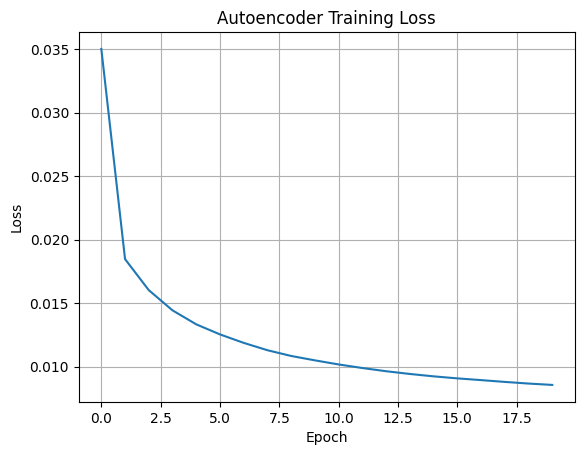

In [ ]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.grid(True)
plt.show()


### plot some examples

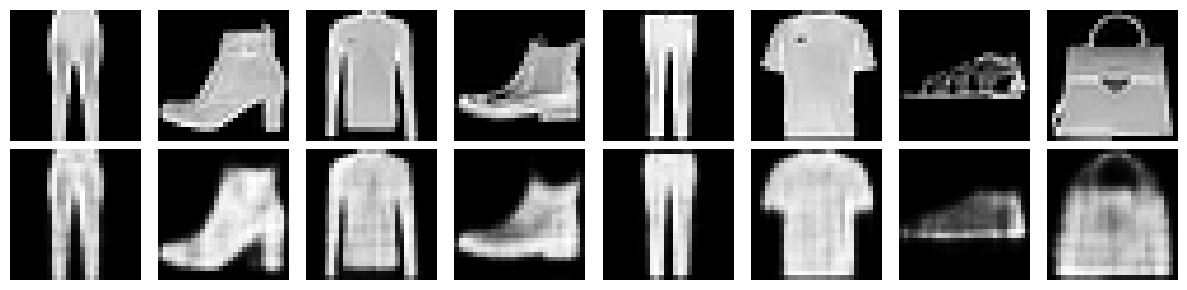

In [ ]:
model.eval()
examples = next(iter(train_loader))[0][:8].to(device)
reconstructions = model(examples).detach().cpu()
fig, axs = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axs[0, i].imshow(examples[i].cpu().squeeze(), cmap='gray')
    axs[0, i].axis('off')
    axs[1, i].imshow(reconstructions[i].squeeze(), cmap='gray')
    axs[1, i].axis('off')
axs[0, 0].set_ylabel("Original")
axs[1, 0].set_ylabel("Reconstructed")
plt.tight_layout()
plt.show()


### Visualisation of the latent space

To better understand how your autoencoder is encoding the data, it’s helpful to visualize the latent representations.

The function below uses t-SNE, a dimensionality reduction technique, to project the high-dimensional latent vectors into 2D space. It then:
- Plots each point in 2D, colored by its class (e.g., digit label).
- Overlays example images on the scatter plot to see what kinds of digits are represented in each part of the latent space.
- This helps us visually assess clustering, separation between classes, and the structure of the learned latent space.

You can call this visualization after training, using a small sample of the validation set and the corresponding labels.

In [ ]:
def visualise_latent_space(X_valid, X_valid_compressed, y_valid):
    from sklearn.manifold import TSNE
    tsne = TSNE()
    X_valid_2D = tsne.fit_transform(X_valid_compressed)
    X_valid_2D = (X_valid_2D - X_valid_2D.min()) / (X_valid_2D.max() - X_valid_2D.min())
    plt.figure(figsize=(10, 8))
    cmap = plt.cm.tab10
    plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap=cmap)
    image_positions = np.array([[1., 1.]])
    for index, position in enumerate(X_valid_2D):
        dist = np.sum((position - image_positions) ** 2, axis=1)
        if np.min(dist) > 0.02: # if far enough from other images
            image_positions = np.r_[image_positions, [position]]
            img = X_valid[index].cpu().numpy().squeeze()  # shape (28, 28)
            imagebox = mpl.offsetbox.AnnotationBbox(
                mpl.offsetbox.OffsetImage(img, cmap="binary"),
                position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
            plt.gca().add_artist(imagebox)
    plt.axis("off")
    plt.show()

def visualise_AE_latent_space(model, train_data):
    X_valid = train_data.data[:1000].float() / 255.0
    X_valid = X_valid.unsqueeze(1).to(device)
    X_valid_compressed = model.encoder(X_valid).detach().cpu()
    y_valid = train_data.targets[:1000]
    visualise_latent_space(X_valid, X_valid_compressed, y_valid)

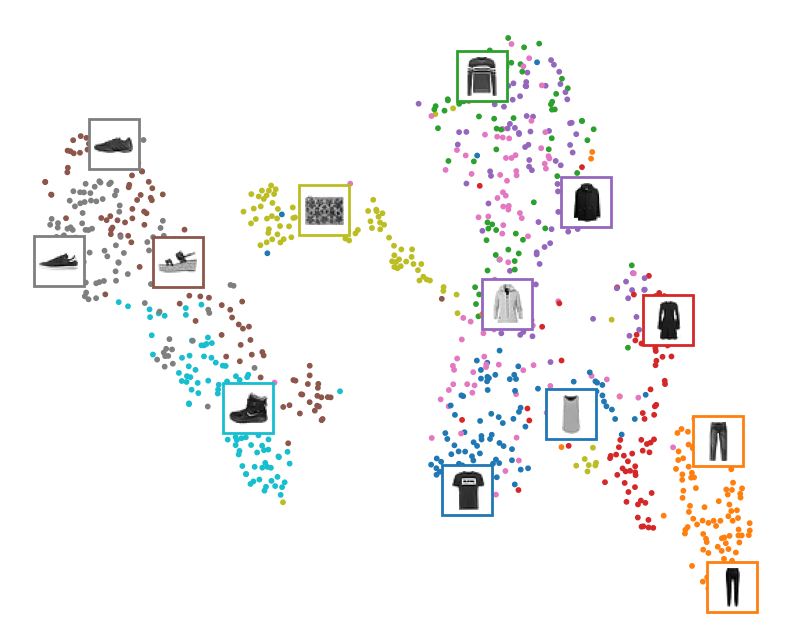

In [ ]:
visualise_AE_latent_space(model, train_data)

# Part 2 - Variational Autoencoder (VAE)

A Variational Autoencoder (VAE) is a generative model that learns not just to reconstruct inputs like a standard autoencoder, but also to generate new data by sampling from a latent space.

Unlike regular autoencoders that map each input to a fixed point in the latent space, a VAE:
- Maps each input to a distribution (typically Gaussian),
- Samples from this distribution during training,
- Adds a regularization term (the KL divergence) to force the latent space to follow a standard normal distribution.

This approach allows the VAE to generate more diverse, realistic samples by decoding random points from a continuous, well-structured latent space.


### 2.1 The Encoder Architecture:
The VAEEncoder is the encoder module of the VAE. It processes the input image and outputs two vectors:
- The mean (mu) of the latent distribution
- The log-variance (logvar) of the latent distribution

These two parameters define the Gaussian distribution from which we sample the latent vector.

Here’s how the encoder is structured:

**Convolutional Layers (self.conv)**
- Input: grayscale image of shape [B, 1, 28, 28]
- A sequence of 3 convolutional layers reduces spatial dimensions:
- Conv1: 1 → 32 channels, size becomes [B, 32, 14, 14]
- Conv2: 32 → 64 channels, size becomes [B, 64, 7, 7]
- Conv3: 64 → 128 channels, size stays [B, 128, 7, 7]
- The output is flattened into a vector of size [B, 128×7×7]

**Fully Connected Layers (self.fc)**
- A Linear layer reduces the size to 256 features and applies ReLU.

**Latent Heads (self.mu and self.logvar)**
- Two separate linear layers generate:
- mu: the mean vector of the latent distribution.
- logvar: the log-variance vector.

**KL Divergence Term**
- The encoder also computes the KL divergence between the predicted Gaussian and the standard normal distribution.
- This term is used later in the VAE’s loss function to regularize the latent space.

In [ ]:
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim=50):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # [B, 32, 14, 14]
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # [B, 64, 7, 7]
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # [B, 128, 7, 7]
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU()
        )
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)
    def forward(self, x):
        h = self.conv(x)
        h = self.fc(h)
        return self.mu(h), self.logvar(h)

### Q2.2 VAE – Decoder Implementation

**Objective**: Implement the decoder part of a Variational Autoencoder (VAE) using PyTorch.
You have already built the VAE encoder, which transforms an image into a latent distribution (mean and log-variance). Now, you will implement the decoder, which takes a sample from the latent space and reconstructs the original image.

Your task is to build a PyTorch nn.Module named VAEDecoder that:
-  Input: Takes a latent vector of size latent_dim (e.g., 50).
- Passes it through two fully connected layers:
	- First layer: latent_dim → 256,
	- ReLU activation.
	- Second layer: 256 → 128 × 7 × 7.
	- ReLU activation.
- Unflattens the output to shape [128, 7, 7] to prepare for convolutional decoding.
- Passes the result through three transposed convolution layers to upscale the image:
	- ConvTranspose2d: (128, 64, kernel_size=3, stride=1, padding=1), preserves shape [7×7]
	- ReLU activation
	- ConvTranspose2d: (64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), upsamples to [14×14]
	- ReLU activation
	- ConvTranspose2d: (32, 1, kernel_size=3, stride=2, padding=1, output_padding=1), upsamples to [28×28]
- Applies a final Sigmoid activation to ensure output pixel values are between 0 and 1.

Use nn.Sequential() blocks to structure your model, and define the forward() method to return the reconstructed image.


In [ ]:
# create the decoder with conv layers
class VAEDecoder(nn.Module):
    def __init__(self, latent_dim=50):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128 * 7 * 7),
            nn.ReLU()
        )
        self.deconv = nn.Sequential(
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1), # [B, 64, 7, 7]
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # [B, 32, 14, 14]
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # [B, 1, 28, 28]
            nn.Sigmoid()
        )
    def forward(self, z):
        h = self.fc(z)
        x_recon = self.deconv(h)
        return x_recon

### 2.3 The VAE full architecture

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=50):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder(latent_dim)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

**VAE Loss** : it combines two components:
- Reconstruction Loss (how well the image is reconstructed)
- KL Divergence (how close the latent distribution is to a standard normal distribution)

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD


**Model instance**: create a model instance with a latent space of dimension 30

In [ ]:
VAE_model = VAE(latent_dim=30).to(device)

In [ ]:
# Training loop for VAE
def train_vae(model, train_loader,optimizer, epochs=20):
    vae_losses = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            recon, mu, logvar = model(images)
            loss = vae_loss(recon, images, mu, logvar)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        vae_losses.append(epoch_loss / len(train_loader))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {vae_losses[-1]:.4f}")
    return losses

### Q2.4 : define the optimizer and run the training loop
Functions to use:
- optim.Adam(model.parameters, lr=1e-3) – to define the optimizer
- losses = train_vae(...)

In [ ]:
optimizer = optim.Adam(VAE_model.parameters(), lr=1e-3)
losses = train_vae(VAE_model, train_loader, optimizer, epochs=20)

Epoch 1/20, Loss: 36227.1274
Epoch 2/20, Loss: 32062.7728
Epoch 3/20, Loss: 31327.0776
Epoch 4/20, Loss: 30975.3381
Epoch 5/20, Loss: 30766.4519
Epoch 6/20, Loss: 30635.3735
Epoch 7/20, Loss: 30538.0409
Epoch 8/20, Loss: 30452.5493
Epoch 9/20, Loss: 30395.8316
Epoch 10/20, Loss: 30345.9014
Epoch 11/20, Loss: 30292.5290
Epoch 12/20, Loss: 30257.7969
Epoch 13/20, Loss: 30217.7481
Epoch 14/20, Loss: 30186.3845
Epoch 15/20, Loss: 30158.9598
Epoch 16/20, Loss: 30132.6342
Epoch 17/20, Loss: 30108.5133
Epoch 18/20, Loss: 30087.1536
Epoch 19/20, Loss: 30074.4326
Epoch 20/20, Loss: 30037.6367


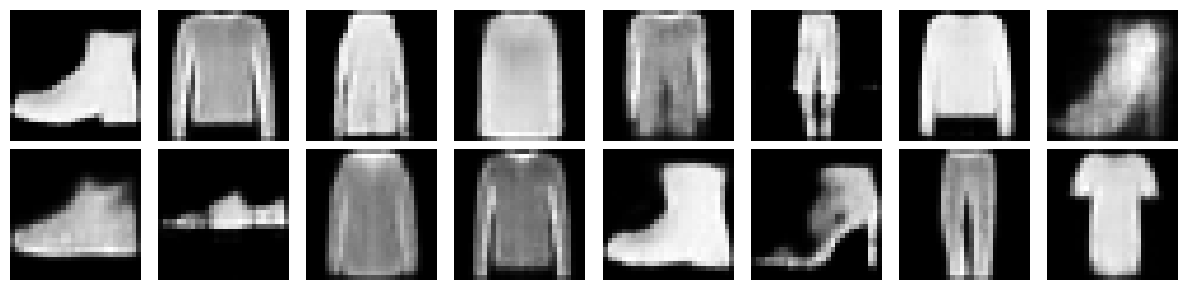

In [ ]:
# Generate some images from the trained VAE
VAE_model.eval()
noise = torch.randn(16, 30).to(device)  # latent_dim=30
generated_images = VAE_model.decoder(noise).detach().cpu()
fig, axs = plt.subplots(2, 8, figsize=(12, 3))
for i in range(2):
    for j in range(8):
        axs[i, j].imshow(generated_images[i*8 + j].squeeze(), cmap='gray')
        axs[i, j].axis('off')
plt.tight_layout()
plt.show()

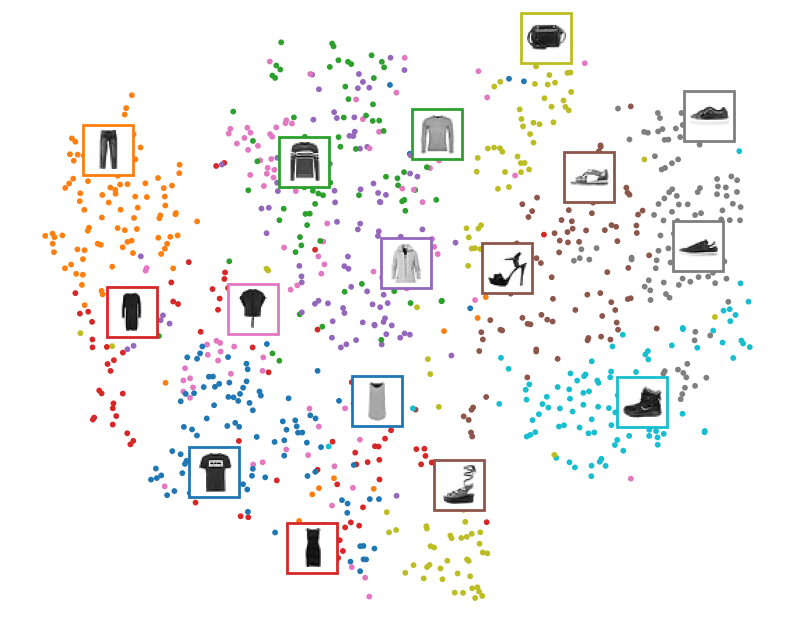

In [ ]:
# visualise the latent space of VAE
def visualise_VAE_latent_space(model, train_data):
    X_valid = train_data.data[:1000].float() / 255.0
    X_valid = X_valid.unsqueeze(1).to(device)
    X_valid_compressed = model.encoder(X_valid)[0].detach().cpu()
    y_valid = train_data.targets[:1000]
    visualise_latent_space(X_valid, X_valid_compressed, y_valid)


visualise_VAE_latent_space(VAE_model, train_data)

#### Now Try with a wider latent space, e.g. dim = 50, and increase the number of epochs to 50

In [ ]:
vae_50 = VAE(latent_dim=50).to(device)
optimizer = optim.Adam(vae_50.parameters(), lr=1e-3)
losses = train_vae(vae_50, train_loader, optimizer, epochs=50)

Epoch 1/50, Loss: 37230.4521
Epoch 2/50, Loss: 32344.2517
Epoch 3/50, Loss: 31490.4758
Epoch 4/50, Loss: 31148.0829
Epoch 5/50, Loss: 30917.6048
Epoch 6/50, Loss: 30771.9842
Epoch 7/50, Loss: 30652.9606
Epoch 8/50, Loss: 30567.6696
Epoch 9/50, Loss: 30496.3504
Epoch 10/50, Loss: 30440.5196
Epoch 11/50, Loss: 30399.3058
Epoch 12/50, Loss: 30357.9995
Epoch 13/50, Loss: 30315.5362
Epoch 14/50, Loss: 30276.8779
Epoch 15/50, Loss: 30242.7833
Epoch 16/50, Loss: 30211.9358
Epoch 17/50, Loss: 30173.8861
Epoch 18/50, Loss: 30148.1998
Epoch 19/50, Loss: 30124.8134
Epoch 20/50, Loss: 30107.2616
Epoch 21/50, Loss: 30093.9241
Epoch 22/50, Loss: 30078.8428
Epoch 23/50, Loss: 30051.0867
Epoch 24/50, Loss: 30043.4225
Epoch 25/50, Loss: 30031.5573
Epoch 26/50, Loss: 30008.2328
Epoch 27/50, Loss: 30005.6987
Epoch 28/50, Loss: 29989.7007
Epoch 29/50, Loss: 29981.1152
Epoch 30/50, Loss: 29963.1750
Epoch 31/50, Loss: 29957.6237
Epoch 32/50, Loss: 29943.5622
Epoch 33/50, Loss: 29936.7026
Epoch 34/50, Loss: 

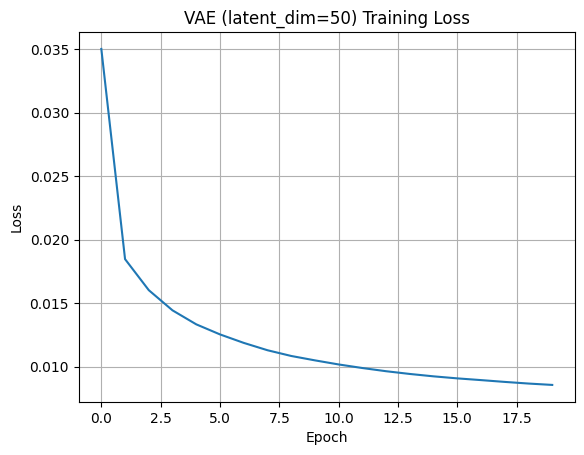

In [ ]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE (latent_dim=50) Training Loss")
plt.grid(True)
plt.show()

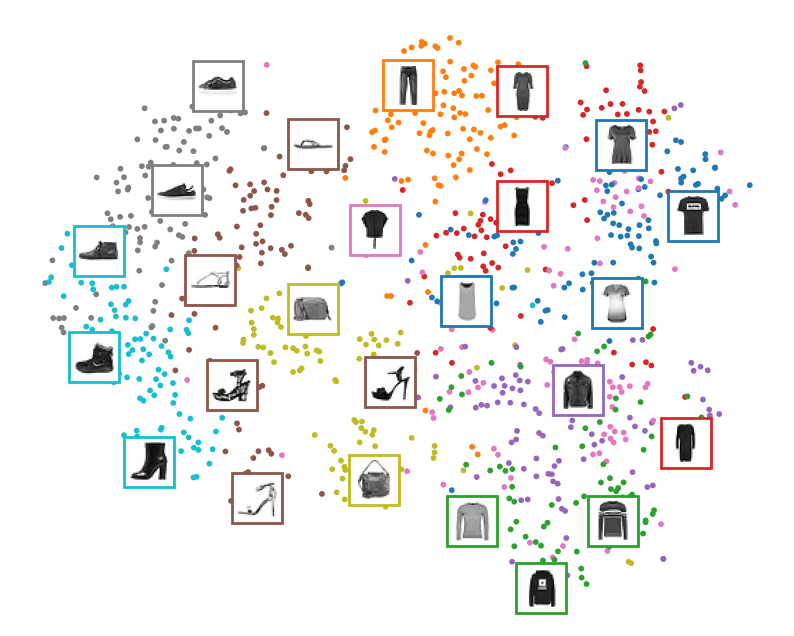

In [ ]:
visualise_VAE_latent_space(vae_50, train_data)

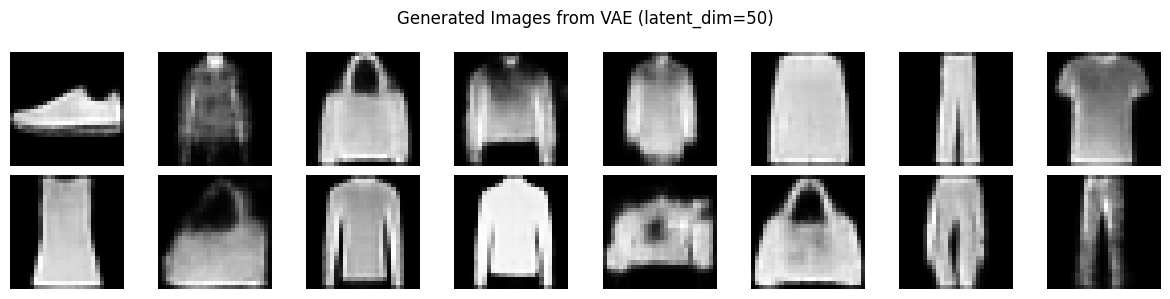

In [ ]:
vae_50.eval()
noise = torch.randn(16, 50).to(device)  # latent_dim=50
generated_images = vae_50.decoder(noise).detach().cpu()
fig, axs = plt.subplots(2, 8, figsize=(12, 3))
for i in range(2):
    for j in range(8):
        axs[i, j].imshow(generated_images[i*8 + j].squeeze(), cmap='gray')
        axs[i, j].axis('off')
plt.suptitle("Generated Images from VAE (latent_dim=50)")
plt.tight_layout()
plt.show()

## Part 3 – Generative Adversarial Network (GAN)

### 3.1 Generator Architecture:
- Takes in random noise (a latent vector) and tries to generate fake images that look like real ones (e.g., MNIST digits).
- Learns to fool the discriminator over time.
- Components:
    - Fully connected layer to expand the latent vector.
    - Output reshaped into a 28×28 image

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Tanh()
        )
    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)


### 3.2 Discriminator architecture:
- Receives both real images (from the dataset) and fake images (from the generator).
- Tries to distinguish real from fake — outputs a probability: “real” (1) or “fake” (0).
- Components:
    - Input: A 28×28 image (real or generated)
    - Flattened input passed through fully connected layers
    - Uses LeakyReLU to allow a small gradient when inactive
    - Final activation: Sigmoid, outputting a probability (real/fake)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)


**Instance setup**

In [ ]:
latent_dim = 100
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)
criterion = nn.BCELoss()
opt_g = optim.Adam(generator.parameters(), lr=2e-4)
opt_d = optim.Adam(discriminator.parameters(), lr=2e-4)


**Check the generator output**

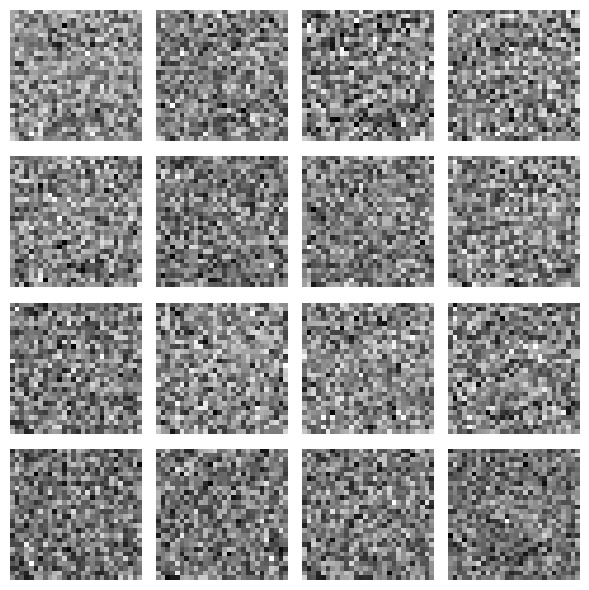

In [ ]:
# Generate some samples from the generator
z = torch.randn(16, latent_dim).to(device)
generated_images = generator(z).detach().cpu()
fig, axs = plt.subplots(4, 4, figsize=(6, 6))
for i in range(4):
    for j in range(4):
        axs[i, j].imshow(generated_images[i*4 + j].squeeze(), cmap='gray')
        axs[i, j].axis('off')
plt.tight_layout()
plt.show()

Discriminator loss on real and fake images: 0.6833


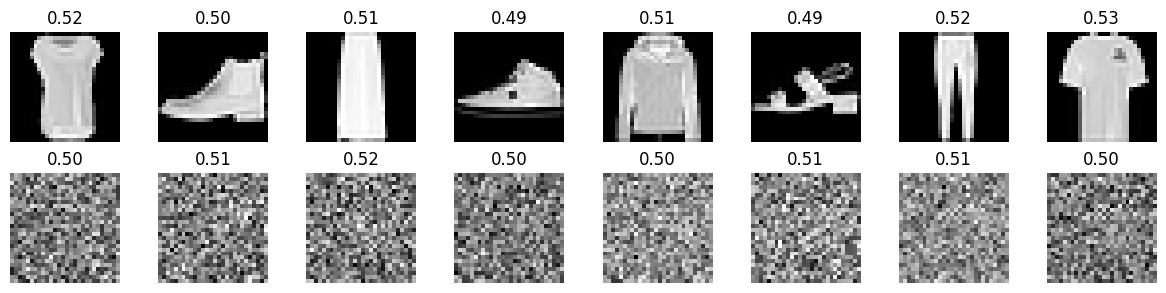

In [ ]:
# Test the discriminator
real_images = next(iter(train_loader))[0][:16].to(device)
real_labels = torch.ones(16, 1).to(device)
fake_images = generator(torch.randn(16, latent_dim).to(device)).detach()
fake_labels = torch.zeros(16, 1).to(device)
real_preds = discriminator(real_images)
fake_preds = discriminator(fake_images)
real_loss = criterion(real_preds, real_labels)
fake_loss = criterion(fake_preds, fake_labels)
d_loss = (real_loss + fake_loss) / 2
print(f"Discriminator loss on real and fake images: {d_loss.item():.4f}")
# show some images from both sets and what are the discriminator outputs
fig, axs = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axs[0, i].imshow(real_images[i].cpu().squeeze(), cmap='gray')
    axs[0, i].set_title(f"{real_preds[i].item():.2f}")
    axs[0, i].axis('off')
    axs[1, i].imshow(fake_images[i].cpu().squeeze(), cmap='gray')
    axs[1, i].set_title(f"{fake_preds[i].item():.2f}")
    axs[1, i].axis('off')
axs[0, 0].set_ylabel("Real")
axs[1, 0].set_ylabel("Fake")
plt.tight_layout()
plt.show()

In [ ]:
def generate_noise(batch_size, latent_dim):
    return torch.randn(batch_size, latent_dim).to(device)


#### Train the GANs

In [ ]:
# Training loop for GANs

def train_GANS(generator, discriminator, train_loader, latent_dim=100, epochs=50):
    g_losses = []
    d_losses = []
    for epoch in range(epochs):
        # Initialize epoch losses
        g_loss_epoch, d_loss_epoch = 0, 0

        # Iterate over the training data
        for real, _ in train_loader:
            real = real.to(device)
            batch_size = real.size(0)

            # === Train Discriminator ===

            # Step 1: Generate fake images
            noise = generate_noise(batch_size, latent_dim)  # Sample random noise vector
            fake = generator(noise)  # Generate fake images from the noise using generator

            # Step 2: Compute discriminator outputs for real and fake images
            d_real = discriminator(real).view(-1)  # Discriminator output on real images
            d_fake = discriminator(fake.detach()).view(-1)  # Discriminator output on fake (detach to avoid updating G)

            # Step 3: Compute discriminator loss
            # - Real images should be classified as 1 (real)
            # - Fake images should be classified as 0 (fake)
            loss_d = criterion(d_real, torch.ones_like(d_real)) + \
                    criterion(d_fake, torch.zeros_like(d_fake))

            # Step 4: Backpropagation and optimization step for discriminator
            opt_d.zero_grad()  # Zero out discriminator gradients
            loss_d.backward()  # Backpropagate discriminator loss
            opt_d.step()       # Update discriminator weights

            # === Train Generator ===

            # Step 5: Generate new fake images (detach not used here since we want gradients to flow)
            noise = generate_noise(batch_size, latent_dim)
            fake = generator(noise)

            # Step 6: Compute discriminator output on the newly generated fake images
            d_output = discriminator(fake).view(-1)

            # Step 7: Compute generator loss
            # - The generator wants the discriminator to think its outputs are real (target = 1)
            loss_g = criterion(d_output, torch.ones_like(d_output))

            # Step 8: Backpropagation and optimization step for generator
            opt_g.zero_grad()  # Zero out generator gradients
            loss_g.backward()  # Backpropagate generator loss
            opt_g.step()       # Update generator weights

            # Accumulate losses for this batch
            d_loss_epoch += loss_d.item()
            g_loss_epoch += loss_g.item()

        # Record average losses for the epoch
        d_losses.append(d_loss_epoch / len(train_loader))
        g_losses.append(g_loss_epoch / len(train_loader))

        # Print losses to track training progress
        print(f"Epoch {epoch+1}: D Loss = {d_losses[-1]:.4f}, G Loss = {g_losses[-1]:.4f}")
    return g_losses, d_losses

In [ ]:
g_losses, d_losses = train_GANS(generator, discriminator, train_loader, latent_dim=latent_dim, epochs=25)

Epoch 1: D Loss = 0.9121, G Loss = 1.0657
Epoch 2: D Loss = 1.1815, G Loss = 0.8905
Epoch 3: D Loss = 1.0723, G Loss = 0.9514
Epoch 4: D Loss = 0.9782, G Loss = 0.9518
Epoch 5: D Loss = 1.1380, G Loss = 0.8999
Epoch 6: D Loss = 1.0711, G Loss = 1.0584
Epoch 7: D Loss = 1.0867, G Loss = 1.0116
Epoch 8: D Loss = 0.8218, G Loss = 1.2471
Epoch 9: D Loss = 1.1116, G Loss = 0.9630
Epoch 10: D Loss = 0.9379, G Loss = 1.1750
Epoch 11: D Loss = 1.0743, G Loss = 1.0081
Epoch 12: D Loss = 1.0080, G Loss = 1.0730
Epoch 13: D Loss = 1.1152, G Loss = 0.9935
Epoch 14: D Loss = 1.1936, G Loss = 1.0028
Epoch 15: D Loss = 1.1062, G Loss = 1.0632
Epoch 16: D Loss = 1.1623, G Loss = 1.0333
Epoch 17: D Loss = 1.1231, G Loss = 1.0306
Epoch 18: D Loss = 1.2130, G Loss = 0.9222
Epoch 19: D Loss = 1.1795, G Loss = 0.9564
Epoch 20: D Loss = 1.1549, G Loss = 1.0162
Epoch 21: D Loss = 1.1841, G Loss = 0.9492
Epoch 22: D Loss = 1.1840, G Loss = 0.9848
Epoch 23: D Loss = 1.1208, G Loss = 1.0403
Epoch 24: D Loss = 1

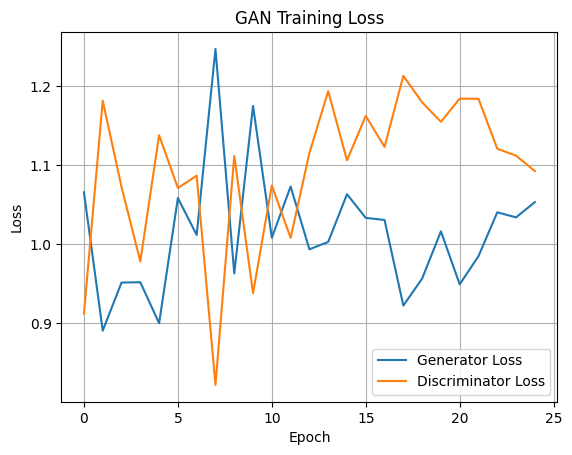

In [ ]:
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("GAN Training Loss")
plt.grid(True)
plt.show()


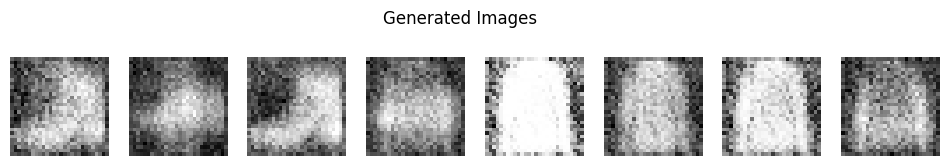

In [ ]:
generator.eval()
noise = generate_noise(8, latent_dim)
samples = generator(noise).detach().cpu()
fig, axs = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axs[i].imshow(samples[i].squeeze(), cmap="gray")
    axs[i].axis("off")
plt.suptitle("Generated Images")
plt.show()


### Q 3.1 : Repeate the training of gans with more epochs, and generate samples for comapison

Epoch 1: D Loss = 1.0615, G Loss = 1.1161
Epoch 2: D Loss = 1.0006, G Loss = 1.1876
Epoch 3: D Loss = 1.0747, G Loss = 1.1030
Epoch 4: D Loss = 1.0320, G Loss = 1.1609
Epoch 5: D Loss = 1.1312, G Loss = 1.0319
Epoch 6: D Loss = 1.1104, G Loss = 1.0740
Epoch 7: D Loss = 0.9932, G Loss = 1.2381
Epoch 8: D Loss = 0.8920, G Loss = 1.3150
Epoch 9: D Loss = 0.9326, G Loss = 1.2710
Epoch 10: D Loss = 0.9345, G Loss = 1.3253
Epoch 11: D Loss = 0.9518, G Loss = 1.3299
Epoch 12: D Loss = 1.0221, G Loss = 1.2691
Epoch 13: D Loss = 0.8549, G Loss = 1.6321
Epoch 14: D Loss = 0.7908, G Loss = 1.5257
Epoch 15: D Loss = 0.9022, G Loss = 1.3351
Epoch 16: D Loss = 0.8337, G Loss = 1.5264
Epoch 17: D Loss = 0.8530, G Loss = 1.4620
Epoch 18: D Loss = 0.8697, G Loss = 1.4707
Epoch 19: D Loss = 0.8069, G Loss = 1.5545
Epoch 20: D Loss = 0.8440, G Loss = 1.4398
Epoch 21: D Loss = 0.8215, G Loss = 1.4951
Epoch 22: D Loss = 0.8764, G Loss = 1.4252
Epoch 23: D Loss = 0.8744, G Loss = 1.4697
Epoch 24: D Loss = 0

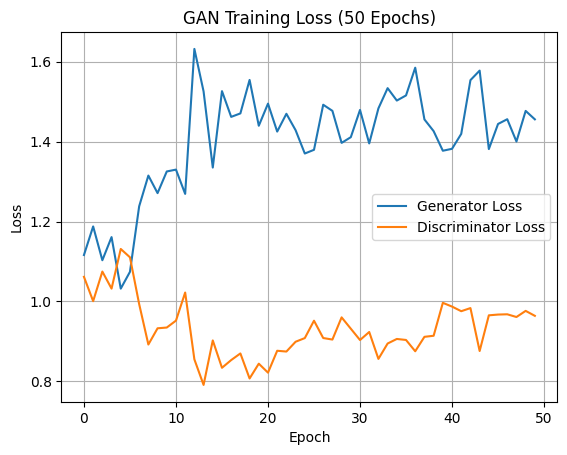

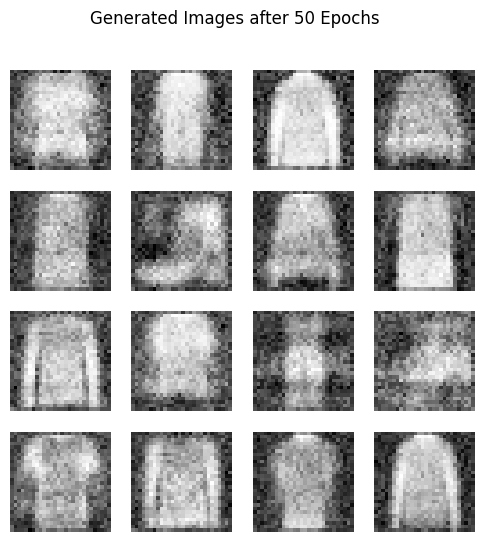

In [ ]:
g_losses_long, d_losses_long = train_GANS(generator, discriminator, train_loader, latent_dim=latent_dim, epochs=50)

plt.plot(g_losses_long, label='Generator Loss')
plt.plot(d_losses_long, label='Discriminator Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("GAN Training Loss (50 Epochs)")
plt.grid(True)
plt.show()

generator.eval()
noise = generate_noise(16, latent_dim)
samples = generator(noise).detach().cpu()
fig, axs = plt.subplots(4, 4, figsize=(6, 6))
for i in range(4):
    for j in range(4):
        axs[i, j].imshow(samples[i*4 + j].squeeze(), cmap="gray")
        axs[i, j].axis("off")
plt.suptitle("Generated Images after 50 Epochs")
plt.show()

### Report : Comments on your findings after trying the previous models for image generation

For image reconstruction and latent space organization, the Autoencoder performed well. For probabilistic generation of new samples, the VAE showed promising results, especially with increased latent dimensions and epochs. The GAN, while showing some improvement, would require more extensive training and tuning to reach its full generative potential.